### Titanic Survival Prediction

You are a data scientist / AI engineer working on a binary classification problem to predict the survival of passengers from the Titanic crash. You have been provided with a dataset named **`"titanic.csv"`** which includes various features of passengers to predict whether they survived or not. The dataset comprises the following columns:

- `passenger_id:` The unique identifier for each passenger.
- `name:` The name of the passenger.
- `p_class:` The passenger class (1 = 1st class, 2 = 2nd class, 3 = 3rd class).
- `sex:` The gender of the passenger.
- `age:` The age of the passenger.
- `sib_sp:` The number of siblings or spouses the passenger had aboard the Titanic.
- `parch:` The number of parents or children the passenger had aboard the Titanic.
- `ticket:` The ticket number of the passenger.
- `fare:` The fare the passenger paid for the ticket.
- `cabin:` The cabin number where the passenger stayed.
- `embarked:` The port where the passenger boarded the Titanic (C = Cherbourg; Q = Queenstown; S = Southampton).
- `survived:` Whether the passenger survived (1) or not (0).

Your task is to use this dataset to build and evaluate a `Gaussian Naive Bayes` model to predict whether a passenger survived based on their features. You will also evaluate the model's performance using precision, recall, and other classification metrics.

**Import Necessary Libraries**

In [1]:
# Import Necessary Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# Step 1: Import the data from the "titanic.csv" file and store it in a variable df
df = pd.read_csv("titanic.csv")

# Step 2: Display the number of rows and columns in the dataset
df.shape     # (891, 12)

# Step 3: Display the first few rows of the dataset to get an overview
df.sample(2)

,passenger_id,name,p_class,sex,age,sib_sp,parch,ticket,fare,cabin,embarked,survived
589,590,"Murdlin, Mr. Joseph",3,male,NaN,0,0,A./5. 3235,8.05,NaN,S,0
618,619,"Becker, Miss. Marion Louise",2,female,4.0,2,1,230136,39.00,F4,S,1


In [5]:
# Step 4: Check for any missing values in the dataset 
df.isnull().sum()

passenger_id      0
name              0
p_class           0
sex               0
age             177
sib_sp            0
parch             0
ticket            0
fare              9
cabin           687
embarked          2
survived          0
dtype: int64

In [12]:
# Step 5: Drop columns that do not add much value (passenger_id, name, sib_sp, parch, ticket, cabin, embarked)
### columns are drop unitensionally 
df.head()

,p_class,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,NaN,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


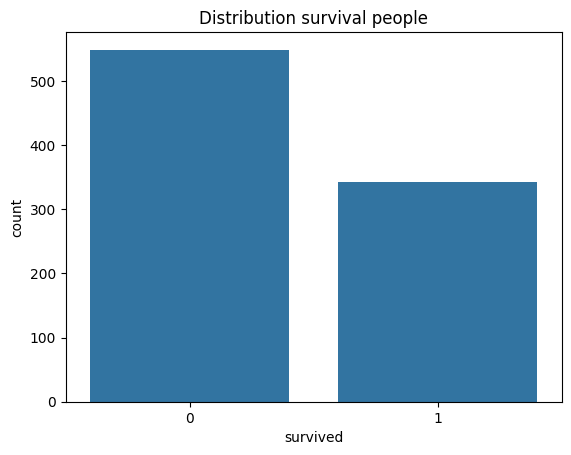

----------------------------------------------------------------------------------------------------


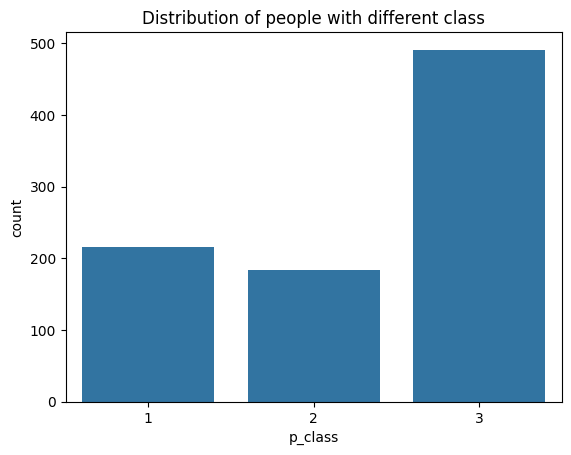

In [19]:
# Step 6: Visualize the distribution

#'survived'
sns.countplot(x= "survived" , data=df)
plt.title("Distribution survival people")
plt.show()


print( "-" * 100)
# 'p_class'
sns.countplot(x="p_class" , data = df)
plt.title("Distribution of people with different class")
plt.show()


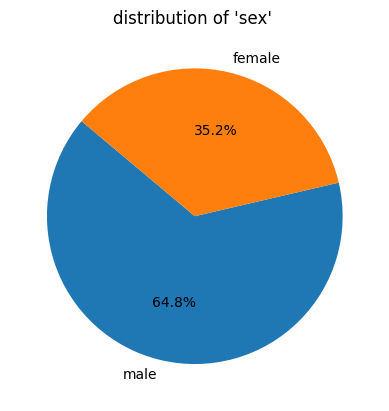

In [34]:
# Step 7: Visualize the distribution of 'sex' using a pie chart (percentage)
sex_count = df.sex.value_counts()
plt.pie(sex_count , labels=sex_count.index ,autopct='%1.1f%%', startangle=140)
plt.title("distribution of 'sex' ")
plt.show()

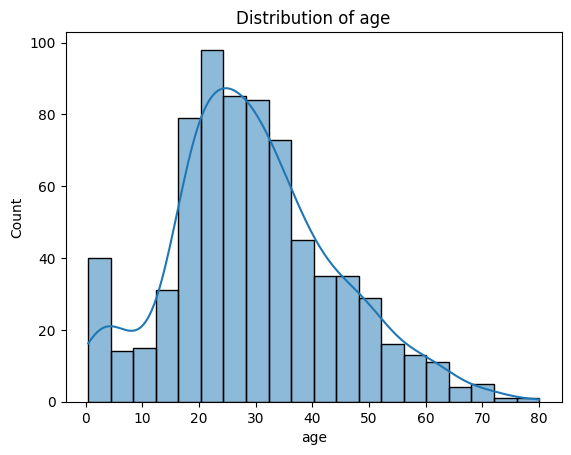

In [39]:
# Step 8: Visualize the distribution of 'age' using a histogram
sns.histplot(x="age" , data=df , kde=True)
plt.title("Distribution of age")
plt.show()

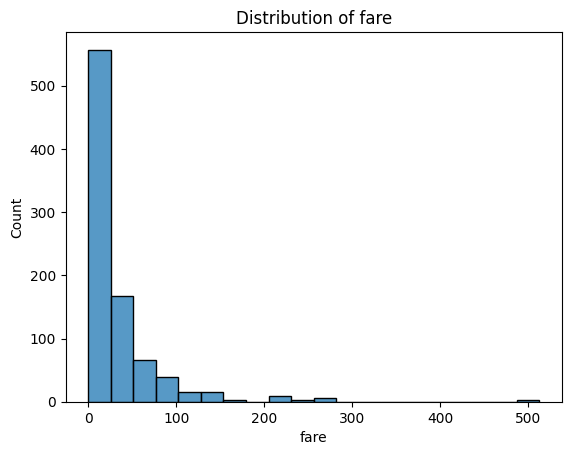

In [43]:
# Step 9: Visualize the distribution of 'fare' using a histogram
sns.histplot(x="fare" , data=df , bins=20)
plt.title("Distribution of fare")
plt.show()

### Task 2: Data Preprocessing

1. Fill in missing values in the `age and fare` columns with their median values.
2. Encode the sex column using one-hot encoding.
3. Standardize the fare column using StandardScaler.
4. Select the features `(p_class, sex, age, fare)` and the target variable `(survived)` for modeling.
5. Split the dataset into training and testing sets with a test size of 30%.

In [50]:
# Step 1: Fill in missing values in the 'age' and 'fare' columns with their median values
median_age = df["age"].median()
median_fare = df["fare"].median()
df["age"].fillna(median_age , inplace=True)
df["fare"].fillna(median_fare , inplace=True)


In [51]:
# check null values 
df.isnull().sum()

p_class     0
sex         0
age         0
fare        0
survived    0
dtype: int64

In [52]:
# null is full filled 
df.iloc[[589]]

,p_class,sex,age,fare,survived
589,3,male,28.0,8.05,0


In [59]:
df.sample(1)

,p_class,age,fare,survived,sex_male
788,3,1.0,20.575,1,True


In [60]:
# Step 2: Encode the 'sex' column using one-hot encoding
# df = pd.get_dummies(df, columns=["sex"], drop_first=True)
df.head(2)

,p_class,age,fare,survived,sex_male
0,3,22.0,7.2500,0,True
1,1,38.0,71.2833,1,False


The sex column is convert into one hot encoding 

In [66]:
# Step 3: Standardize the 'fare' column using StandardScaler
scaler = StandardScaler()
df["fare"] = scaler.fit_transform(df[['fare']])
df.head()

,p_class,age,fare,survived,sex_male
0,3,22.0,-0.500819,0,True
1,1,38.0,0.788518,1,False
2,3,26.0,-0.355760,1,False
3,1,35.0,0.422390,1,False
4,3,35.0,-0.484711,0,True


In [70]:
# Step 4: Select the features and target variable for modeling
features = ["p_class" , "age" , "fare" , "sex_male"]
X = df[features]
y = df["survived"]
# Step 5: Split the dataset into training and testing sets with a test size of 30%
X_train , X_test , Y_train , Y_test = train_test_split(X , y , test_size = 0.3 , random_state=42)


### Task 3: Model Training Using Gaussian Naive Bayes

1. Initialize and train a `Gaussian Naive Bayes` model using the training data.
2. Make predictions on the test set using the trained model.
3. Evaluate the model using a classification report and print the report.
4. Visualize the confusion matrix for the model.

In [74]:
# Step 1: Initialize and train a Gaussian Naive Bayes model using the training data
model = GaussianNB()
model.fit(X_train , Y_train)


# Step 2: Make predictions on the test set using the trained model
y_pred = model.predict(X_test)

In [76]:
# Step 3: Evaluate the model using a classification report and print the report
report = classification_report(Y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.80      0.81       157
           1       0.73      0.74      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



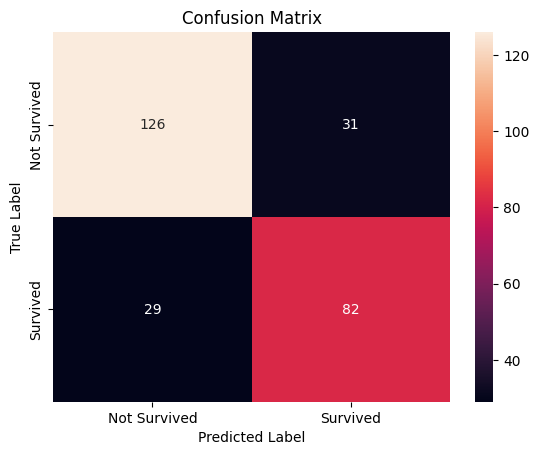

In [84]:
# Step 4: Visualize the confusion matrix for the model
cm = confusion_matrix(Y_test , y_pred)
sns.heatmap(cm , annot=True , fmt="d", xticklabels=['Not Survived', 'Survived'] , yticklabels=["Not Survived" , "Survived"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()